In [ ]:
## Computational Environment
using Random, CSV, DataFrames, Distributions, Survival, NTRsurv, Plots, LaTeXStrings
Random.seed!(1234)

TaskLocalRNG()

In [7]:
tongue = rcopy(R"tongue")

Row,type,time,delta
,Int64,Int64,Int64
1,1,1,1
2,1,3,1
3,1,3,1
4,1,4,1
5,1,10,1
6,1,13,1
7,1,13,1
8,1,16,1
9,1,16,1


In [8]:
T = float.(tongue[!,:time])
δ = tongue[!,:delta];

In [9]:
Tₑ = T[ δ .== 1 ]
Tₒ = T[ δ .== 0 ];

In [10]:
mean(Tₑ)

49.698113207547166

In [11]:
sum(δ)

53

In [12]:
km = fit(KaplanMeier, T, δ)

KaplanMeier{Float64, Float64}(EventTable{Float64}([1.0, 3.0, 4.0, 5.0, 8.0, 10.0, 12.0, 13.0, 16.0, 18.0  …  129.0, 131.0, 150.0, 157.0, 167.0, 176.0, 181.0, 231.0, 240.0, 400.0], [2, 3, 2, 2, 1, 1, 1, 3, 2, 1  …  1, 0, 0, 1, 1, 0, 1, 0, 0, 0], [0, 0, 0, 0, 1, 0, 0, 0, 0, 0  …  0, 1, 1, 0, 0, 1, 0, 2, 1, 1], [80, 78, 75, 73, 71, 69, 68, 67, 64, 62  …  11, 10, 9, 8, 7, 6, 5, 4, 2, 1]), [0.975, 0.9375, 0.9125000000000001, 0.8875000000000001, 0.8750000000000001, 0.8623188405797103, 0.8496376811594205, 0.8115942028985509, 0.7862318840579712, 0.7735507246376814  …  0.2883605848313903, 0.2883605848313903, 0.2883605848313903, 0.2523155117274665, 0.21627043862354273, 0.21627043862354273, 0.1730163508988342, 0.1730163508988342, 0.1730163508988342, 0.1730163508988342], [0.01790287185098582, 0.028867513459481287, 0.034621238235890715, 0.03980586693257064, 0.042257712736425826, 0.04470842219836276, 0.04709919104246099, 0.05401815123202459, 0.058497802698822765, 0.06071575813144969  …  0.2129794971

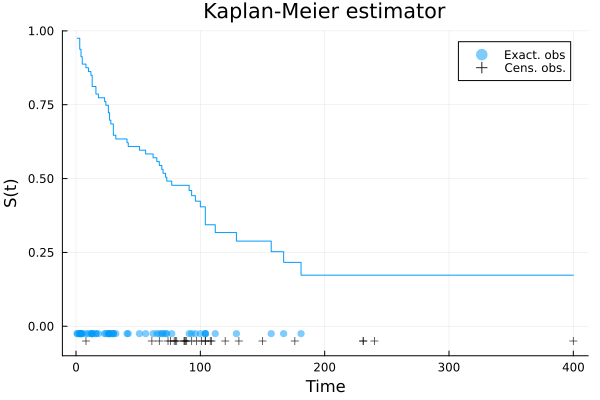

In [13]:
plot(km.events.time,km.survival, seriestype = :steppost, ylim=(-0.1,1), xlabel = "Time", ylabel = "S(t)", label = "", title="Kaplan-Meier estimator")
scatter!( Tₑ, zeros(sum(δ)) .- 0.025, markerstrokewidth=0.0, color = 1, alpha=0.5, label="Exact. obs")
scatter!( Tₒ, zeros(length(δ)-sum(δ)) .- 0.05, marker=:cross, color = :black, alpha=0.75, label="Cens. obs.")

In [14]:
# Create NTRsurv structures
data = SurvivalData(T,δ)
info_baseline = EmpiricalBayesBaseline(data);

In [15]:
println("The baseline mean is ", 1/info_baseline.κ(1.0))

The baseline mean is 49.69811320754717


In [16]:
# Plotting time grid
t =  collect(LinRange(0.0,400,200));

In [19]:
# Prior elicitation
prior_band_d_info, prior_band_m_info, prior_band_u_info = prior_credible_band(0.05,3000,t,1.0,info_baseline)

([1.0, 0.09133340024874576, 0.09133340024853372, 0.040647722094105596, 0.04064742545538729, 0.03941182897735313, 0.039411826248529576, 0.03795864571786473, 0.03766509256879554, 0.03766509256879554  …  5.3083326751825236e-12, 4.287539604063399e-12, 4.28753960405135e-12, 4.286973564955565e-12, 4.254234764637544e-12, 4.254195266904776e-12, 3.329256183702643e-12, 3.3292459708993307e-12, 1.9991522371842134e-12, 1.9991522371842134e-12], [1.0, 0.9618344910387087, 0.9298427417239956, 0.8943343183449722, 0.8578879428213686, 0.821071733804706, 0.7891823761116148, 0.759823631428393, 0.7289810869326561, 0.7006834190359662  …  0.0004573808534159425, 0.0004362458310613675, 0.00042191726063026916, 0.0004121287985456836, 0.0003933799706113198, 0.00038531464880898683, 0.00037614456266807757, 0.0003636653318497869, 0.00034318888501207845, 0.0003260332275595896], [1.0, 1.0, 1.0, 1.0, 0.9999999999999978, 0.9999999999999724, 0.9999999999597889, 0.9999999989104267, 0.9999999989082312, 0.9999999989082312  … 

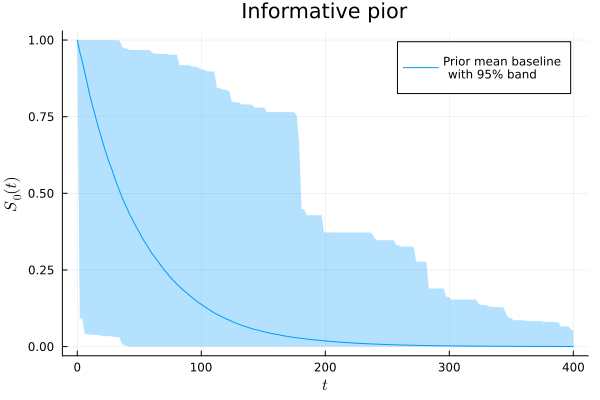

In [104]:
info_prior_plt = plot(t, prior_band_m_info,  ribbon = (prior_band_m_info .- prior_band_d_info, prior_band_u_info .- prior_band_m_info), fillalpha=0.3, xlabel="\$t\$", ylabel="\$S_0(t)\$", label="Prior mean baseline \n with 95% band",  title="Informative pior", size=(600,400))

In [105]:
savefig("InfoPriorTongueData.png")

"/home/alan/Dropbox/NTRsurvPackage/Notebooks/Production/InfoPriorTongueData.png"

In [17]:
# Set informative NTR model
model_info = NeutralToTheRightModel( 1.0, info_baseline, data)

LoadError: MethodError: no method matching NeutralToTheRightModel(::Float64, ::Baseline, ::NTRsurv.SurvivalDataRep)
The type `NeutralToTheRightModel` exists, but no method is defined for this combination of argument types when trying to construct it.

[0mClosest candidates are:
[0m  NeutralToTheRightModel(::Float64, [91m::SurvivalData[39m)
[0m[90m   @[39m [35mNTRsurv[39m [90m~/NTRsurv.jl/src/[39m[90m[4mNTRsurvPrior.jl:270[24m[39m


In [26]:
posterior_band_d_info, posterior_band_m_info, posterior_band_u_info = posterior_credible_band(0.05,3000,t,model_info)

([1.0, 0.8599640756935032, 0.7960188254898979, 0.7568831475610092, 0.7167506137493344, 0.7065177472030573, 0.704926790295517, 0.6612494136808036, 0.6206821822320058, 0.6134826590372707  …  0.0057998927252846414, 0.005799892725284337, 0.005799892723613598, 0.005799892723604887, 0.005799355036301669, 0.005799355036301669, 0.005699641111436776, 0.005699640758289981, 0.005699640758289981, 0.005699640337559966], [1.0, 0.9745651385054143, 0.912440915833462, 0.8872740842955773, 0.8740051755960421, 0.8604894795198557, 0.847037934791702, 0.8095458821431566, 0.7843251669111697, 0.7711838112974259  …  0.06465388632602587, 0.06408233689979125, 0.06349129734273125, 0.06295599700369389, 0.06238838258467956, 0.061827419070160886, 0.06128297879498199, 0.06073310164191797, 0.06015879156721753, 0.059605677406035854], [1.0, 0.9997285033849647, 0.9841278019332239, 0.9732950530309107, 0.971599749500326, 0.9572373220681999, 0.9496540629379558, 0.9201960243088051, 0.9028031412916582, 0.8963747173511728  …  0

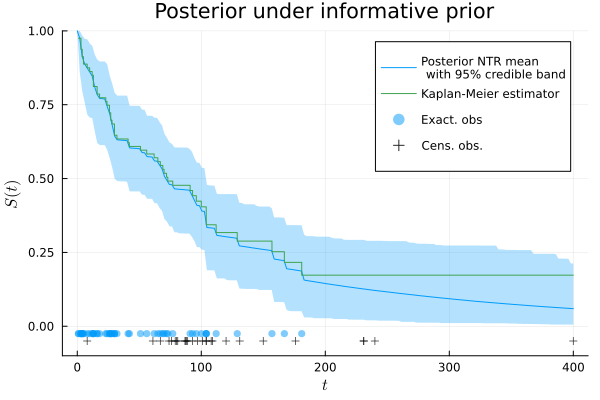

In [115]:
plot(t, posterior_band_m_info,  ribbon = (posterior_band_m_info .- posterior_band_d_info, posterior_band_u_info .- posterior_band_m_info),  ylim=(-0.1,1), fillalpha=0.3, label="Posterior NTR mean \n with 95% credible band",size=(600,400))
plot!(km.events.time,km.survival, seriestype = :steppost, c=3, xlabel = "\$t\$", ylabel = "\$S(t)\$", label = "Kaplan-Meier estimator", title="Posterior under informative prior")
scatter!( Tₑ, zeros(sum(δ)) .- 0.025, markerstrokewidth=0.0, color = 1, alpha=0.5, label="Exact. obs")
scatter!( Tₒ, zeros(length(δ)-sum(δ)) .- 0.05, marker=:cross, color = :black, alpha=0.75, label="Cens. obs.")

In [116]:
savefig("InfoTailTongueData.png")

"/home/alan/Dropbox/NTRsurvPackage/Notebooks/Production/InfoTailTongueData.png"

For a flatter tail behaviour we can select a more non-informative baseline

In [60]:
noninfo_baseline = ExponentialBaseline(0.001);

In [61]:
println("The baseline mean is ", 1/noninfo_baseline.κ(1.0))

The baseline mean is 1000.0


In [62]:
prior_band_d_noninfo, prior_band_m_noninfo, prior_band_u_noninfo = prior_credible_band(0.05,3000,t,1.0,noninfo_baseline)

([1.0, 0.15095687272744646, 0.15095687272744646, 0.15095687272744646, 0.15095687272744646, 0.1506284736991131, 0.1506284736991131, 0.1506284736991131, 0.1506284736991131, 0.1506284736990988  …  0.120086705402997, 0.120086705402997, 0.120086705402997, 0.120086705402997, 0.120086705402997, 0.120086705402997, 0.120086705402997, 0.120086705402997, 0.120086705402997, 0.120086705402997], [1.0, 0.9976077251421787, 0.9960107330904777, 0.9948547032887309, 0.9931245805017496, 0.9918411022448114, 0.990138319487857, 0.988458109613861, 0.9866526223969554, 0.985630456093256  …  0.7219642477785425, 0.7208496752507416, 0.7191076821449075, 0.7180467032397383, 0.7170974259595629, 0.7160095367782734, 0.715560459935205, 0.7145299567467467, 0.713552257184589, 0.7127024123215118], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0  …  0.9999998874166174, 0.9999998874166174, 0.9999998874166174, 0.9999998874166174, 0.9999998874166174, 0.9999998874166174, 0.9999998874166174, 0.9999998874166174, 0.99999988741661

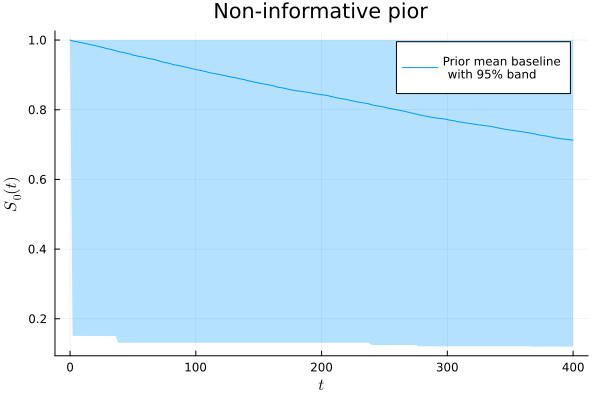

In [109]:
plot(t, prior_band_m_noninfo,  ribbon = (prior_band_m_noninfo .- prior_band_d_noninfo, prior_band_u_noninfo .- prior_band_m_noninfo), fillalpha=0.3, xlabel="\$t\$", ylabel="\$S_0(t)\$", label="Prior mean baseline \n with 95% band",  title="Non-informative pior", size=(600,400))

In [110]:
savefig("NonInfoPriorTongueData.png")

"/home/alan/Dropbox/NTRsurvPackage/Notebooks/Production/NonInfoPriorTongueData.png"

In [64]:
# Set non-informative NTR model 1
model_noninfo = NeutralToTheRightModel( 1.0, noninfo_baseline, data)

NTRsurv.NeutralToTheRightModelRep(1.0, 1.4426950408889634, Baseline(NTRsurv.var"#ExponentialBaseline##0#ExponentialBaseline##1"{Float64}(0.001), NTRsurv.var"#ExponentialBaseline##2#ExponentialBaseline##3"{Float64}(0.001), NTRsurv.var"#ExponentialBaseline##4#ExponentialBaseline##5"{Float64}(0.001)), NTRsurv.SurvivalDataRep([1.0, 3.0, 4.0, 5.0, 8.0, 10.0, 12.0, 13.0, 16.0, 18.0  …  129.0, 131.0, 150.0, 157.0, 167.0, 176.0, 181.0, 231.0, 240.0, 400.0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1  …  1, 0, 0, 1, 1, 0, 1, 0, 0, 0], 80, 59, [2, 3, 2, 2, 1, 1, 1, 3, 2, 1  …  1, 0, 0, 1, 1, 0, 1, 0, 0, 0], [1, 2, 3, 4, 5, 6, 7, 8, 9, 10  …  39, 40, 41, 43, 45, 48, 50, 53, 54, 56], [80, 78, 75, 73, 71, 69, 68, 67, 64, 62  …  10, 9, 8, 7, 6, 5, 4, 2, 1, 0], [78, 75, 73, 71, 70, 68, 67, 64, 62, 61  …  10, 9, 7, 6, 6, 4, 4, 2, 1, 0]))

In [65]:
posterior_band_d_noninfo, posterior_band_m_noninfo, posterior_band_u_noninfo = posterior_credible_band(0.05,3000,t,model_noninfo)

([1.0, 0.8848834164642015, 0.7826852103900853, 0.7439334416824505, 0.7383856261067894, 0.7254137644402533, 0.7110999080670951, 0.6654567274009957, 0.6273870690088811, 0.6096616485494185  …  0.03905069260181086, 0.03905069260181026, 0.03905069260181026, 0.03905069260181026, 0.03905069260181026, 0.03905069260181026, 0.03905069260181026, 0.03905069260181026, 0.03905069260181026, 0.03905069260181026], [1.0, 0.9751411503219041, 0.9134005317828991, 0.8891020796363387, 0.8765983352214453, 0.8640806395067733, 0.8518805228008607, 0.8150651096682017, 0.7902541441438683, 0.7777501936004791  …  0.19096018008084722, 0.19086642571621393, 0.19079339162674977, 0.19072496424624086, 0.1905702428727786, 0.1904689683135458, 0.19043919448443244, 0.19031447029005882, 0.1902583626401732, 0.19017497672508127], [1.0, 0.9995362056600245, 0.9792248023506158, 0.972080040447551, 0.9691324073481086, 0.9556871170925828, 0.9517556437863185, 0.9320074600985319, 0.9164818935696127, 0.8987358057391922  …  0.340646729938

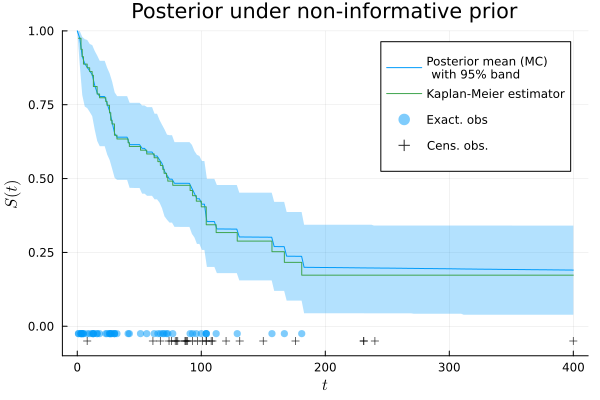

In [112]:
plot(t, posterior_band_m_noninfo,  ribbon = (posterior_band_m_noninfo .- posterior_band_d_noninfo, posterior_band_u_noninfo .- posterior_band_m_noninfo), ylim=(-0.1,1), fillalpha=0.3, label="Posterior mean (MC) \n with 95% band",size=(600,400))
plot!(km.events.time,km.survival, seriestype = :steppost, xlabel = "\$t\$", ylabel = "\$S(t)\$", c=3, label = "Kaplan-Meier estimator", title="Posterior under non-informative prior")
scatter!( Tₑ, zeros(sum(δ)) .- 0.025, markerstrokewidth=0.0, color = 1, alpha=0.5, label="Exact. obs")
scatter!( Tₒ, zeros(length(δ)-sum(δ)) .- 0.05, marker=:cross, color = :black, alpha=0.75, label="Cens. obs.")

In [113]:
savefig("NonInfoTailTongueData.png")

"/home/alan/Dropbox/NTRsurvPackage/Notebooks/Production/NonInfoTailTongueData.png"